# Smart Expense Tracker Application

This project is a Python-based ***Smart Expense Tracker Application*** that helps users log, analyze, 
and visualize their expenses. It integrates:

- Control Structures & Arrays  
- Object-Oriented Programming (OOP)  
- NumPy & Pandas  
- Matplotlib & Seaborn  

---


In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("expenses.csv")
df.head()



,Date,Amount,Category,Description,Payment_Method,Merchant,Location,Currency,Is_Recurring,Month,Year,Day,User_ID,Expense_ID,Notes
0,2023-09-29,664.95,Shopping,Expense for Shopping,Credit Card,Merchant_41,Delhi,INR,True,9,2023,29,13,EXP1,Note 1
1,2023-01-14,3406.39,Food,Expense for Food,Cash,Merchant_7,Chennai,EUR,True,1,2023,14,88,EXP2,Note 2
2,2023-01-08,4341.13,Utilities,Expense for Utilities,Net Banking,Merchant_26,Delhi,USD,False,1,2023,8,42,EXP3,Note 3
3,2023-09-12,384.61,Transport,Expense for Transport,Net Banking,Merchant_37,Mumbai,EUR,True,9,2023,12,81,EXP4,Note 4
4,2024-01-30,1992.19,Utilities,Expense for Utilities,Cash,Merchant_17,Mumbai,EUR,True,1,2024,30,97,EXP5,Note 5


In [244]:
print(df.shape)

(1500, 15)


In [245]:
print(df.columns)

Index(['Date', 'Amount', 'Category', 'Description', 'Payment_Method',
       'Merchant', 'Location', 'Currency', 'Is_Recurring', 'Month', 'Year',
       'Day', 'User_ID', 'Expense_ID', 'Notes'],
      dtype='object')


In [246]:
print(df.dtypes)

Date               object
Amount            float64
Category           object
Description        object
Payment_Method     object
Merchant           object
Location           object
Currency           object
Is_Recurring         bool
Month               int64
Year                int64
Day                 int64
User_ID             int64
Expense_ID         object
Notes              object
dtype: object


In [247]:
print(df.tail())

            Date   Amount       Category                Description  \
1495  2024-02-05   485.76  Entertainment  Expense for Entertainment   
1496  2023-07-05  3258.96         Health         Expense for Health   
1497  2023-05-18   507.17         Health         Expense for Health   
1498  2023-07-26   626.13      Education      Expense for Education   
1499  2024-05-01  4949.62      Education      Expense for Education   

     Payment_Method     Merchant   Location Currency  Is_Recurring  Month  \
1495    Net Banking   Merchant_1  Bangalore      INR          True      2   
1496           Cash  Merchant_34  Bangalore      EUR         False      7   
1497           Cash  Merchant_27  Hyderabad      USD          True      5   
1498    Net Banking  Merchant_25  Bangalore      EUR         False      7   
1499           Cash  Merchant_44    Chennai      INR         False      5   

      Year  Day  User_ID Expense_ID      Notes  
1495  2024    5       78    EXP1496  Note 1496  
1496  2023  

In [248]:

# Dataset info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1500 non-null   object 
 1   Amount          1500 non-null   float64
 2   Category        1500 non-null   object 
 3   Description     1500 non-null   object 
 4   Payment_Method  1500 non-null   object 
 5   Merchant        1500 non-null   object 
 6   Location        1500 non-null   object 
 7   Currency        1500 non-null   object 
 8   Is_Recurring    1500 non-null   bool   
 9   Month           1500 non-null   int64  
 10  Year            1500 non-null   int64  
 11  Day             1500 non-null   int64  
 12  User_ID         1500 non-null   int64  
 13  Expense_ID      1500 non-null   object 
 14  Notes           1500 non-null   object 
dtypes: bool(1), float64(1), int64(4), object(9)
memory usage: 165.7+ KB


,Amount,Month,Year,Day,User_ID
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2538.540520,5.614667,2023.386667,15.902667,51.290667
std,1432.253078,3.163889,0.487149,8.762137,29.025526
min,54.650000,1.000000,2023.000000,1.000000,1.000000
25%,1300.442500,3.000000,2023.000000,8.000000,27.000000
50%,2553.220000,5.000000,2023.000000,16.000000,52.000000
75%,3777.912500,8.000000,2024.000000,23.000000,77.000000
max,4999.590000,12.000000,2024.000000,31.000000,100.000000


## Visualization: Correlations and Distributions

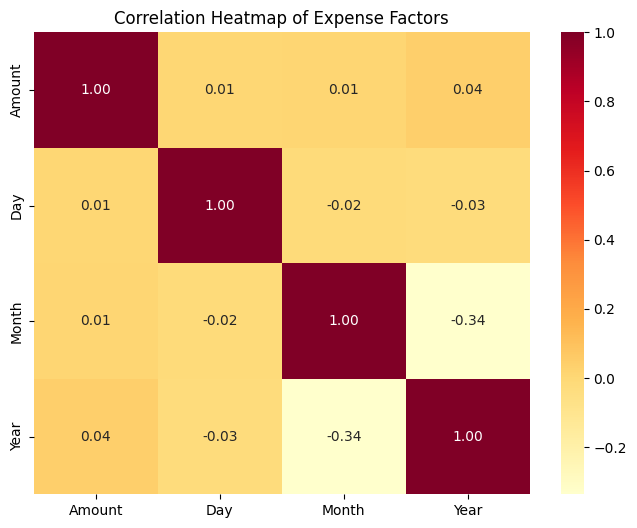

In [249]:


# Select numeric columns
num_cols = ['Amount', 'Day', 'Month', 'Year']

# Compute correlation matrix
corr = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Correlation Heatmap of Expense Factors")
plt.show()


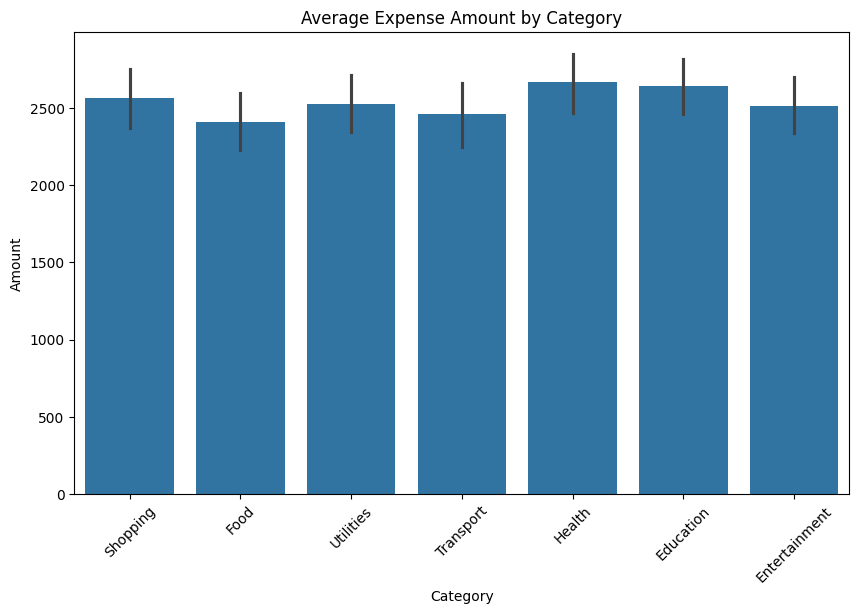

In [250]:
plt.figure(figsize=(10,6))
sns.barplot(x="Category", y="Amount", data=df, estimator="mean")
plt.title("Average Expense Amount by Category")
plt.xticks(rotation=45)
plt.show()



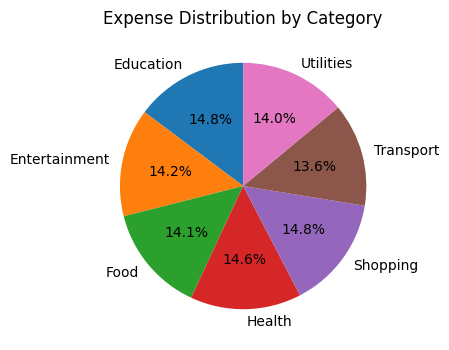

In [251]:
plt.figure(figsize=(8,4))
category_data = df.groupby("Category")["Amount"].sum()
plt.pie(category_data, labels=category_data.index, autopct="%1.1f%%", startangle=90)
plt.title("Expense Distribution by Category")
plt.show()


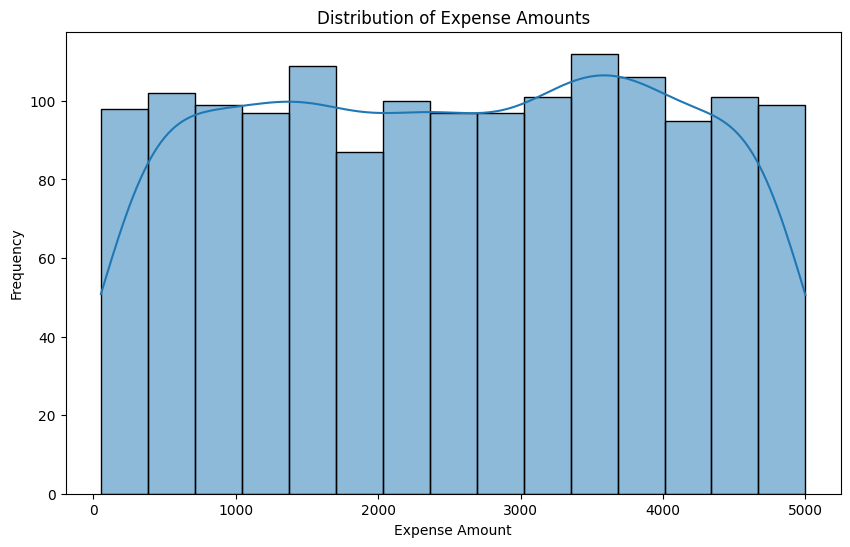

In [252]:
plt.figure(figsize=(10,6))
sns.histplot(df["Amount"], bins=15, kde=True)
plt.title("Distribution of Expense Amounts")
plt.xlabel("Expense Amount")
plt.ylabel("Frequency")
plt.show()


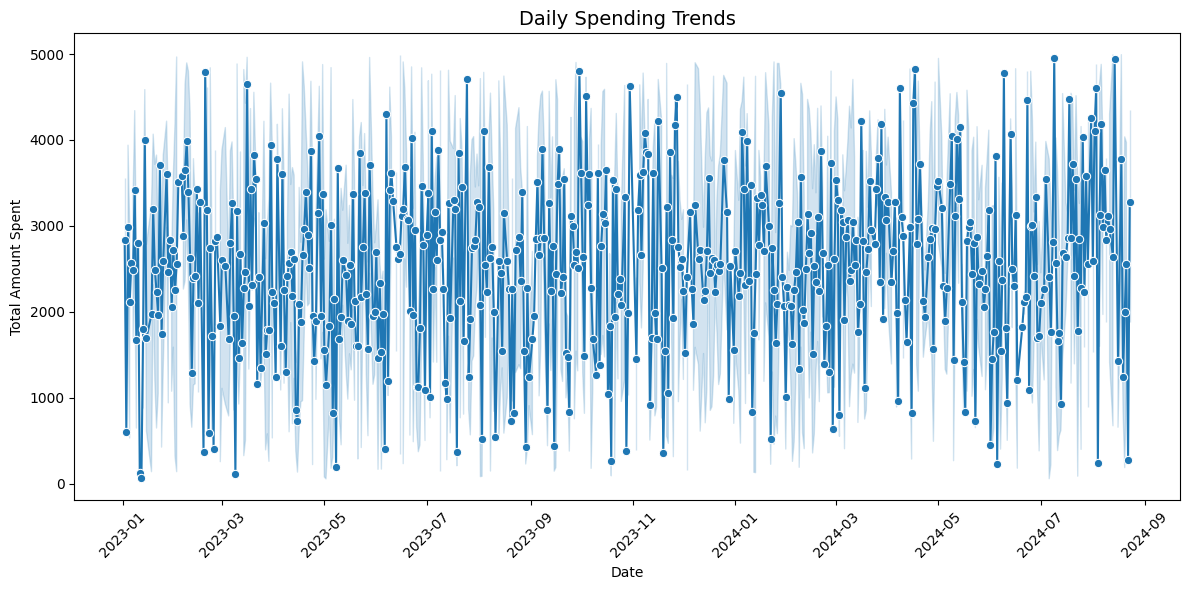

In [7]:
plt.figure(figsize=(12,6))
sns.lineplot(df, x="Date", y="Amount", marker="o")
plt.title("Daily Spending Trends", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

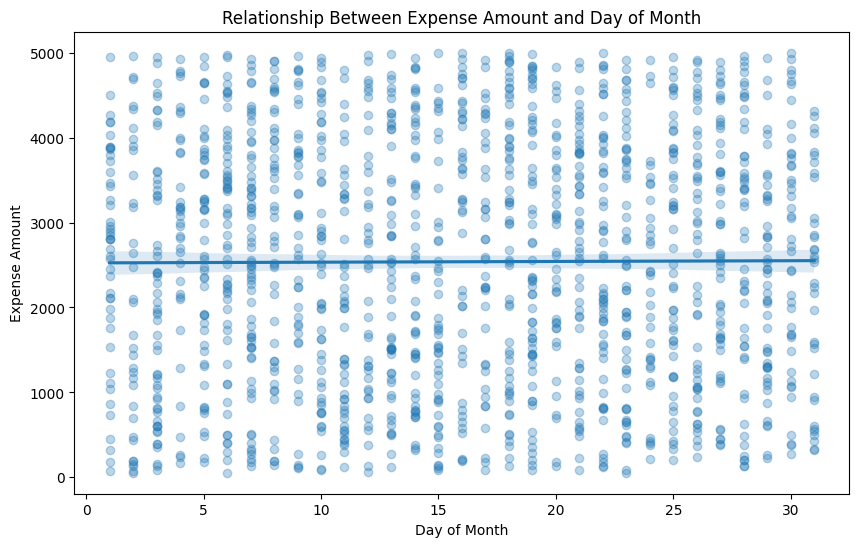

In [5]:


# Extract Day of Month
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Day"] = df["Date"].dt.day

plt.figure(figsize=(10,6))
sns.regplot(x="Day", y="Amount", data=df, scatter_kws={'alpha':0.3})
plt.title("Relationship Between Expense Amount and Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Expense Amount")
plt.show()




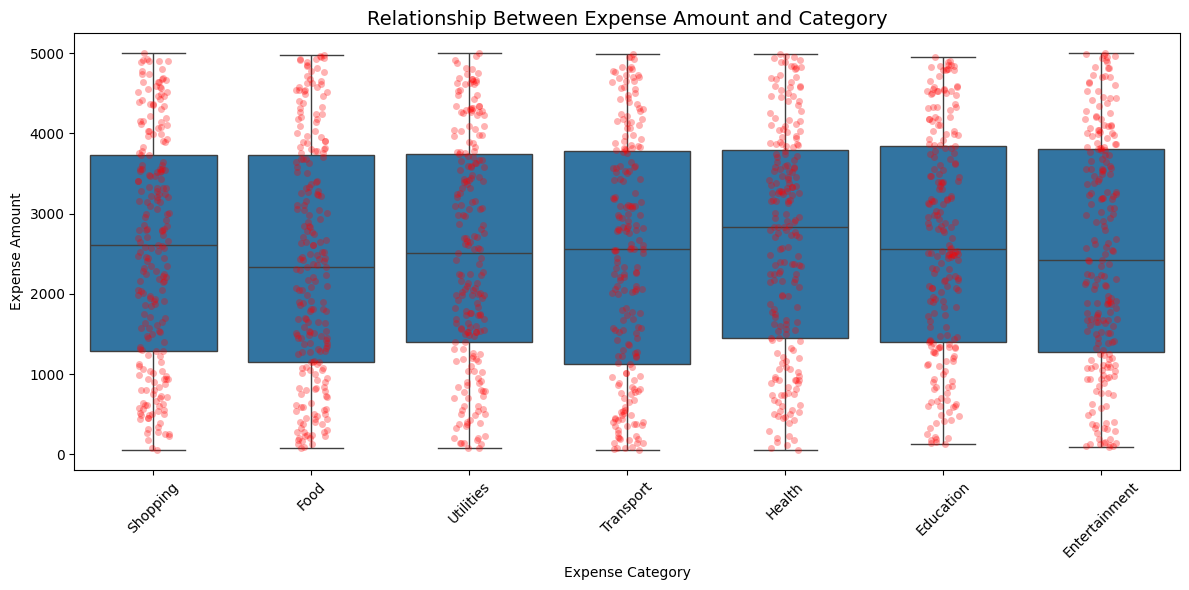

In [4]:


plt.figure(figsize=(12,6))

# Boxplot shows distribution of expenses per category
sns.boxplot(x="Category", y="Amount", data=df, showfliers=False)

# Stripplot overlays individual data points
sns.stripplot(x="Category", y="Amount", data=df, color="red", alpha=0.3, jitter=True)

plt.title("Relationship Between Expense Amount and Category", fontsize=14)
plt.xlabel("Expense Category")
plt.ylabel("Expense Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


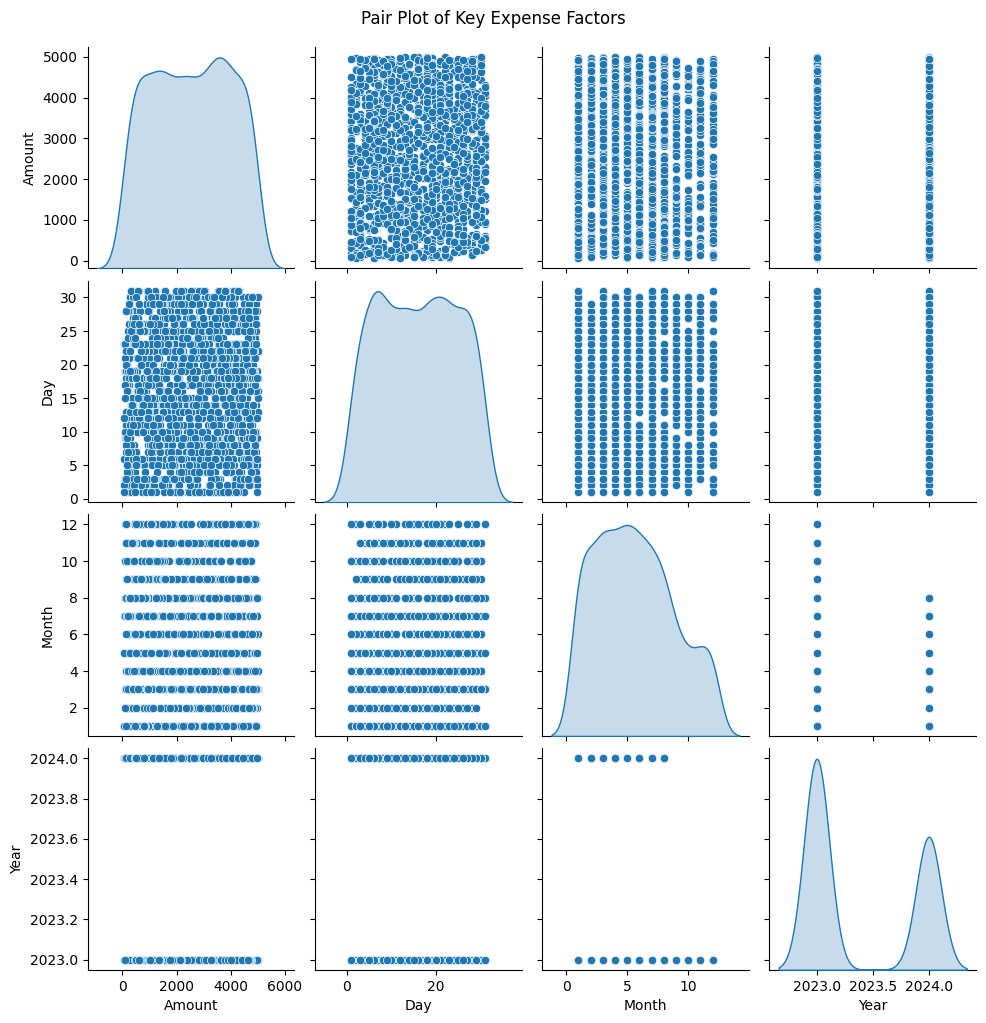

In [253]:


# Select numeric columns for pairplot
num_cols = ['Amount', 'Day', 'Month', 'Year']

sns.pairplot(df[num_cols], diag_kind='kde')
plt.suptitle("Pair Plot of Key Expense Factors", y=1.02)
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_21416\2429497014.py:12: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


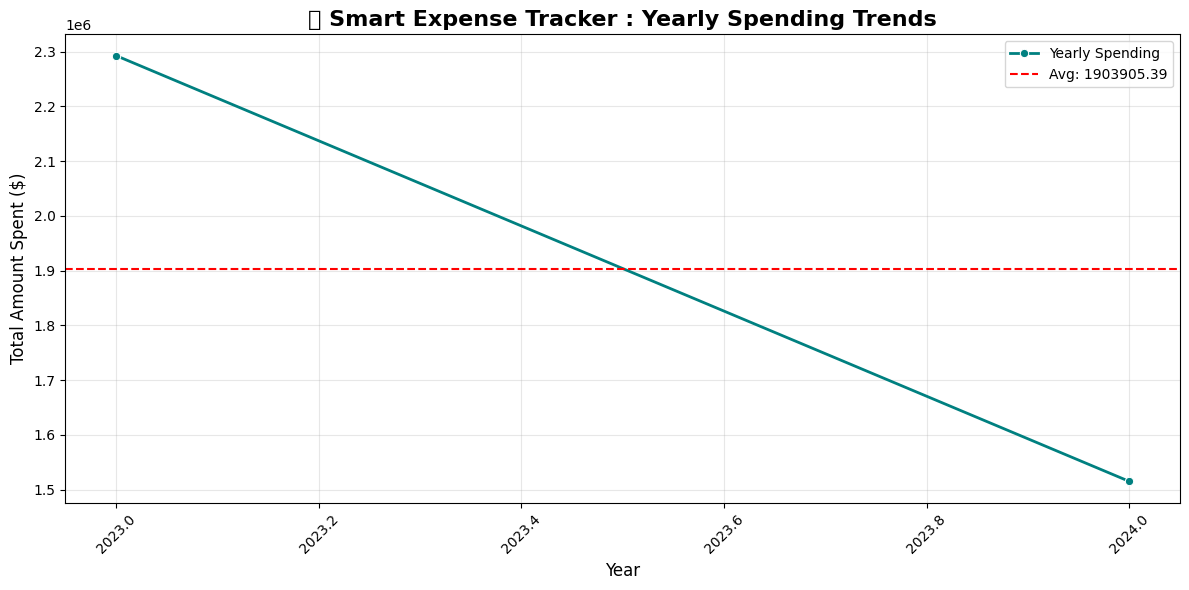

In [8]:
yearly_expense = df.groupby('Year')['Amount'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x="Year", y="Amount", data=yearly_expense, marker="o", linewidth=2, color="teal", label="Yearly Spending")
avg_year_expense = yearly_expense['Amount'].mean()
plt.axhline(avg_year_expense, color="red", linestyle="--", label=f"Avg: {avg_year_expense:.2f}")
plt.title("💰 Smart Expense Tracker : Yearly Spending Trends", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Amount Spent ($)", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
